<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°09

**Objetivo**: Aplicar un flujo completo de **Machine Learning supervisado** para la clasificación de tumores mamarios, utilizando técnicas de preprocesamiento, reducción de dimensionalidad y modelos de clasificación con optimización de hiperparámetros.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.





<img src="https://www.svgrepo.com/show/1064/virus.svg" width = "300" align="center"/>



El **cáncer de mama** es una enfermedad caracterizada por la proliferación maligna de células epiteliales en los conductos o lobulillos mamarios. Surge cuando una célula acumula mutaciones que le otorgan la capacidad de dividirse de manera descontrolada, lo que da origen a un tumor. Este tumor puede permanecer localizado o, en casos más agresivos, invadir tejidos cercanos y propagarse a otras partes del organismo mediante metástasis.

El conjunto de datos **`BC.csv`** recopila información clínica y morfológica de pacientes con tumores mamarios, clasificados como **benignos** o **malignos**. Las características se obtienen a partir de imágenes digitalizadas de aspirados con aguja fina (FNA, por sus siglas en inglés) de masas mamarias. Dichas variables describen aspectos cuantitativos de los **núcleos celulares**, como su tamaño, forma, textura y homogeneidad.

Este tipo de información es fundamental para la detección temprana y clasificación de tumores, ya que permite entrenar modelos de **machine learning** capaces de apoyar el diagnóstico y diferenciar entre tumores benignos y malignos con mayor precisión.

A continuación, se procederá a cargar y explorar el conjunto de datos:



In [ ]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importar herramientas de Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configuración de gráficos
%matplotlib inline
sns.set_palette("deep", desat=0.6)
sns.set(rc={'figure.figsize': (11.7, 8.27)})

# Cargar y preparar los datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/BC.csv")
df.set_index('id', inplace=True)

# Transformación de la variable objetivo
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

# Visualizar las primeras filas del DataFrame
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Con base en la información presentada, resuelva las siguientes tareas. Asegúrese de:

* Incluir el **código necesario** para ejecutar cada análisis.
* Explicar de manera **clara y fundamentada** los resultados obtenidos.
* Describir el **proceso seguido**, justificando las decisiones tomadas en cada etapa (preprocesamiento, elección de técnicas y parámetros, interpretación de resultados).





1. **Análisis exploratorio profundo (EDA):**

   * Examine la distribución de las variables, identifique valores atípicos y analice la correlación entre características.
   * Visualice las diferencias más relevantes entre tumores **benignos** y **malignos** utilizando gráficos adecuados (boxplots, histogramas, mapas de calor).
   * Discuta qué variables parecen tener mayor capacidad discriminativa.


Descripción estadística de las variables numéricas:


,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400



Valores nulos por columna:


,0



Distribución de la variable objetivo (diagnosis):


,proportion
diagnosis,
0,0.627417
1,0.372583


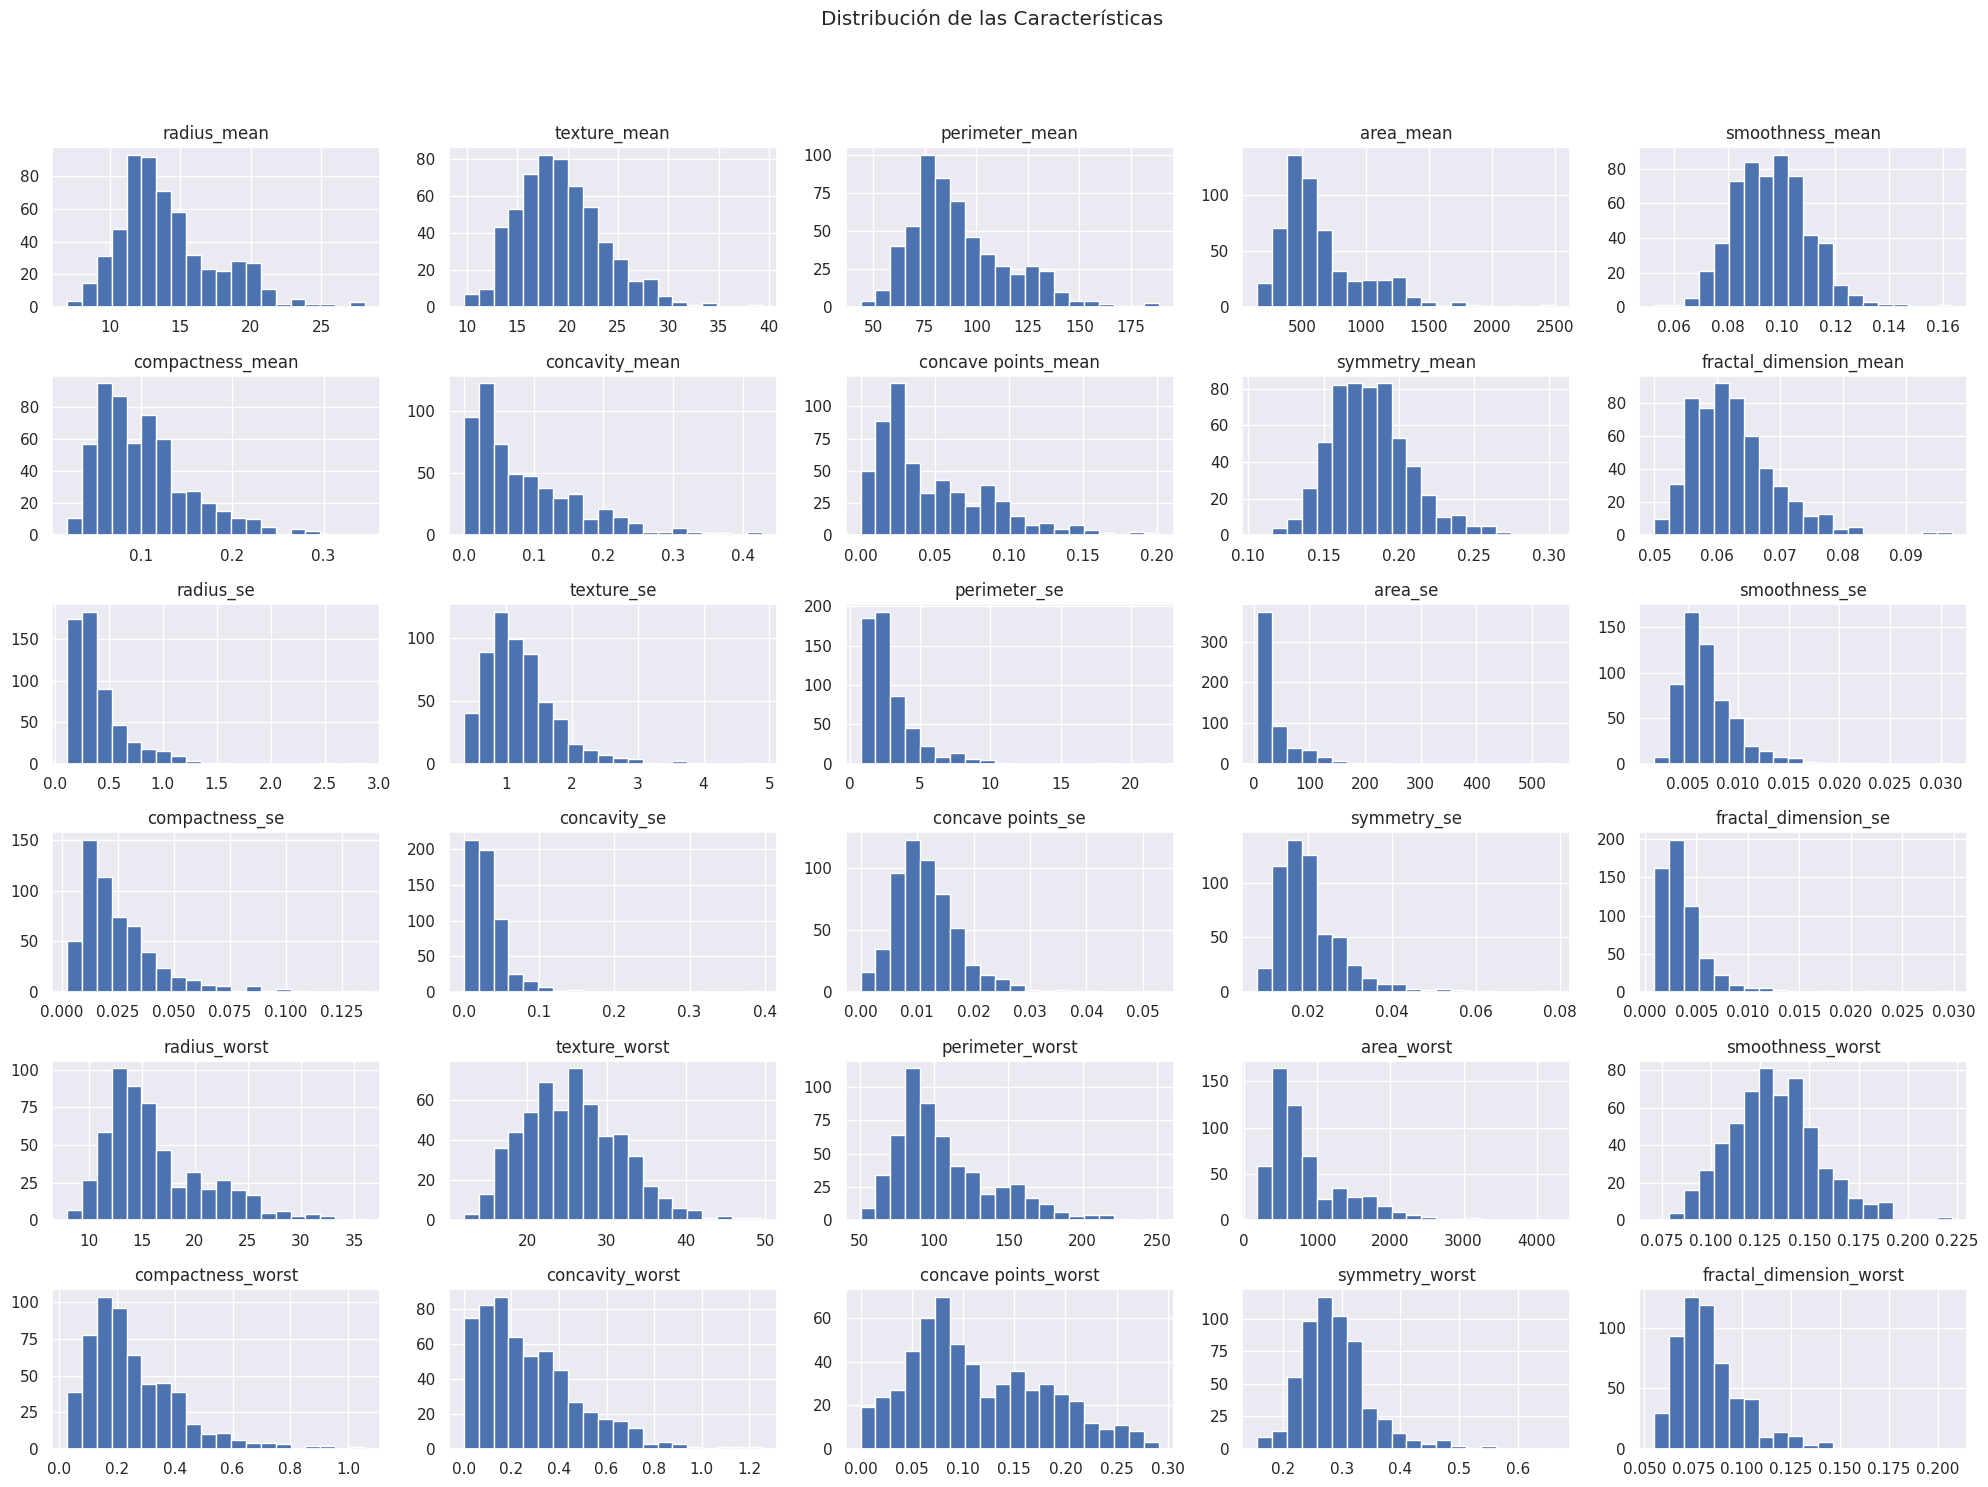

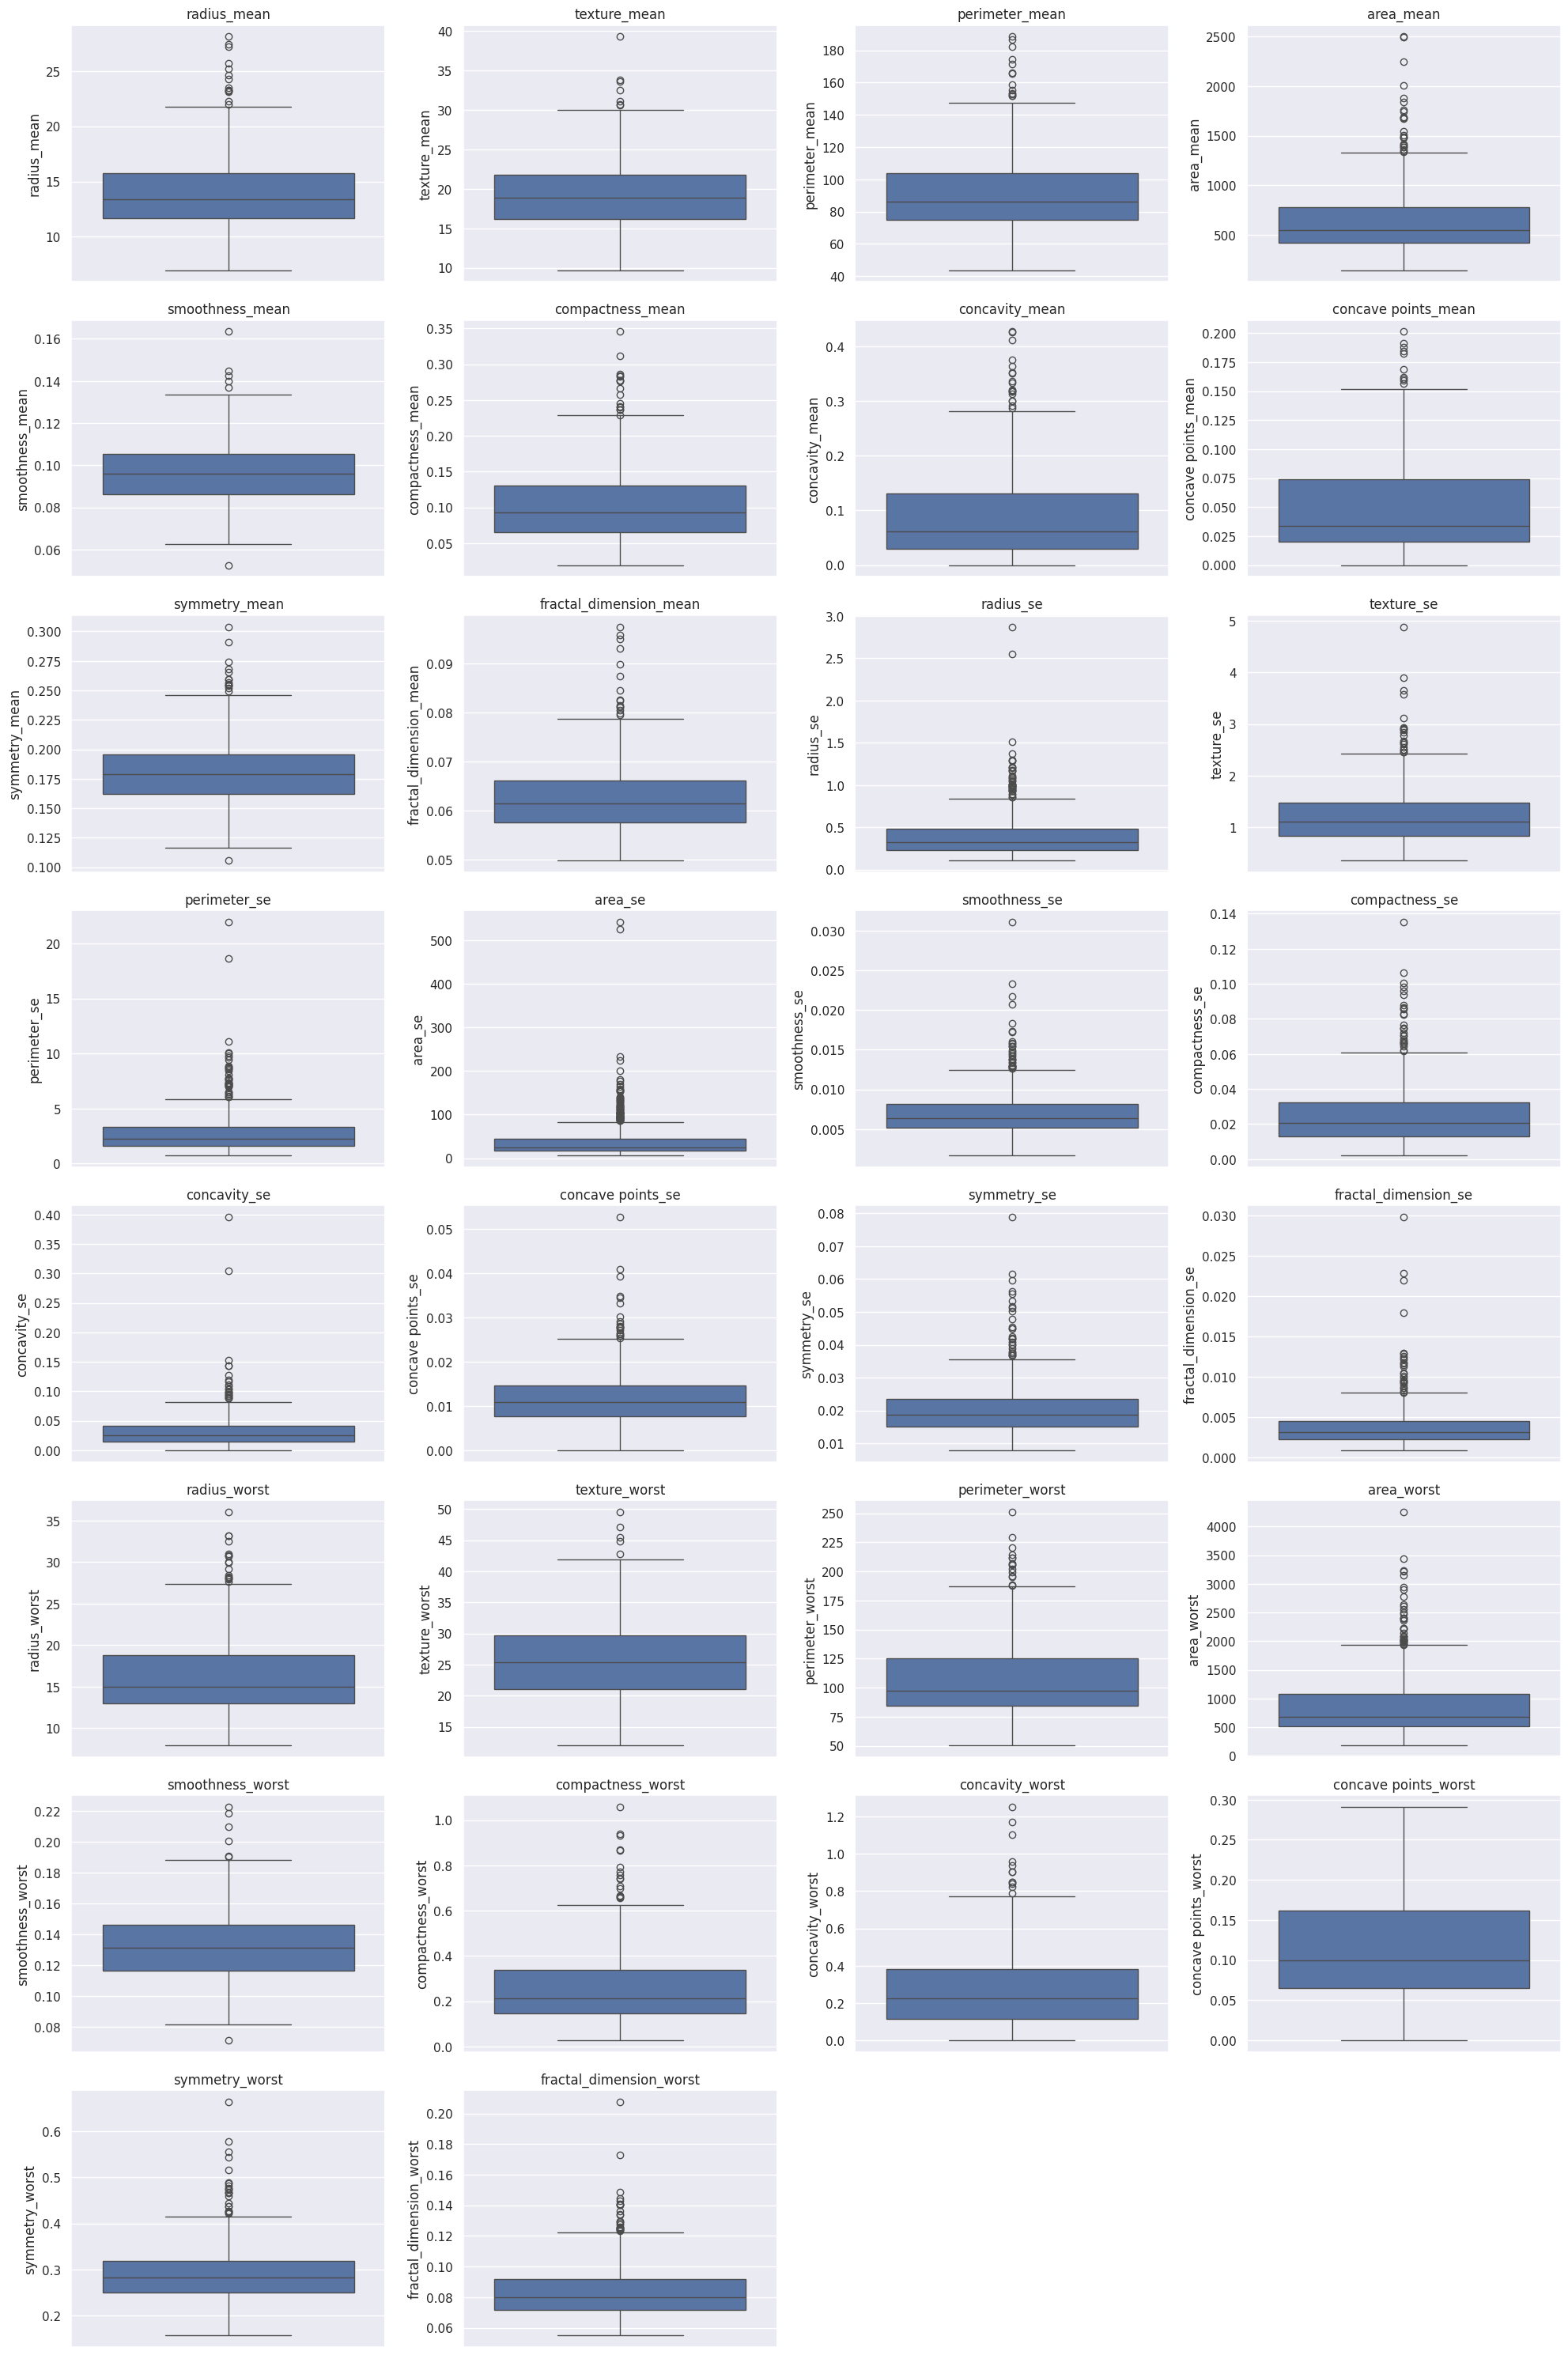

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar y preparar los datos si 'df' no está definido globalmente
# Esto es para asegurar que el dataframe 'df' esté disponible si la celda anterior no se ejecutó o el kernel se reinició.
if 'df' not in globals():
    df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/BC.csv")
    df.set_index('id', inplace=True)
    df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

# Configuración de gráficos (repetir para seguridad)
%matplotlib inline
sns.set_palette("deep", desat=0.6)
sns.set(rc={'figure.figsize': (11.7, 8.27)})

# 1. Análisis exploratorio profundo (EDA)

# Descripción estadística de las variables
print('Descripción estadística de las variables numéricas:')
display(df.describe().T)

# Verificación de valores nulos
print('\nValores nulos por columna:')
display(df.isnull().sum()[df.isnull().sum() > 0])

# Distribución de la variable objetivo
print('\nDistribución de la variable objetivo (diagnosis):')
display(df['diagnosis'].value_counts(normalize=True))

# Visualización de la distribución de las variables numéricas y detección de outliers
# Utilizaremos histogramas para la distribución y boxplots para los outliers.

# Separar las características (X) y la variable objetivo (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Histograma de todas las características
X.hist(bins=20, figsize=(20, 15))
plt.suptitle('Distribución de las Características', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# Boxplots para identificar outliers en las características
plt.figure(figsize=(20, 30))
for i, column in enumerate(X.columns):
    plt.subplot(8, 4, i + 1) # Ajustar el layout según el número de columnas
    sns.boxplot(y=X[column])
    plt.title(column)
plt.tight_layout()
plt.show()


Mapa de calor de correlación:


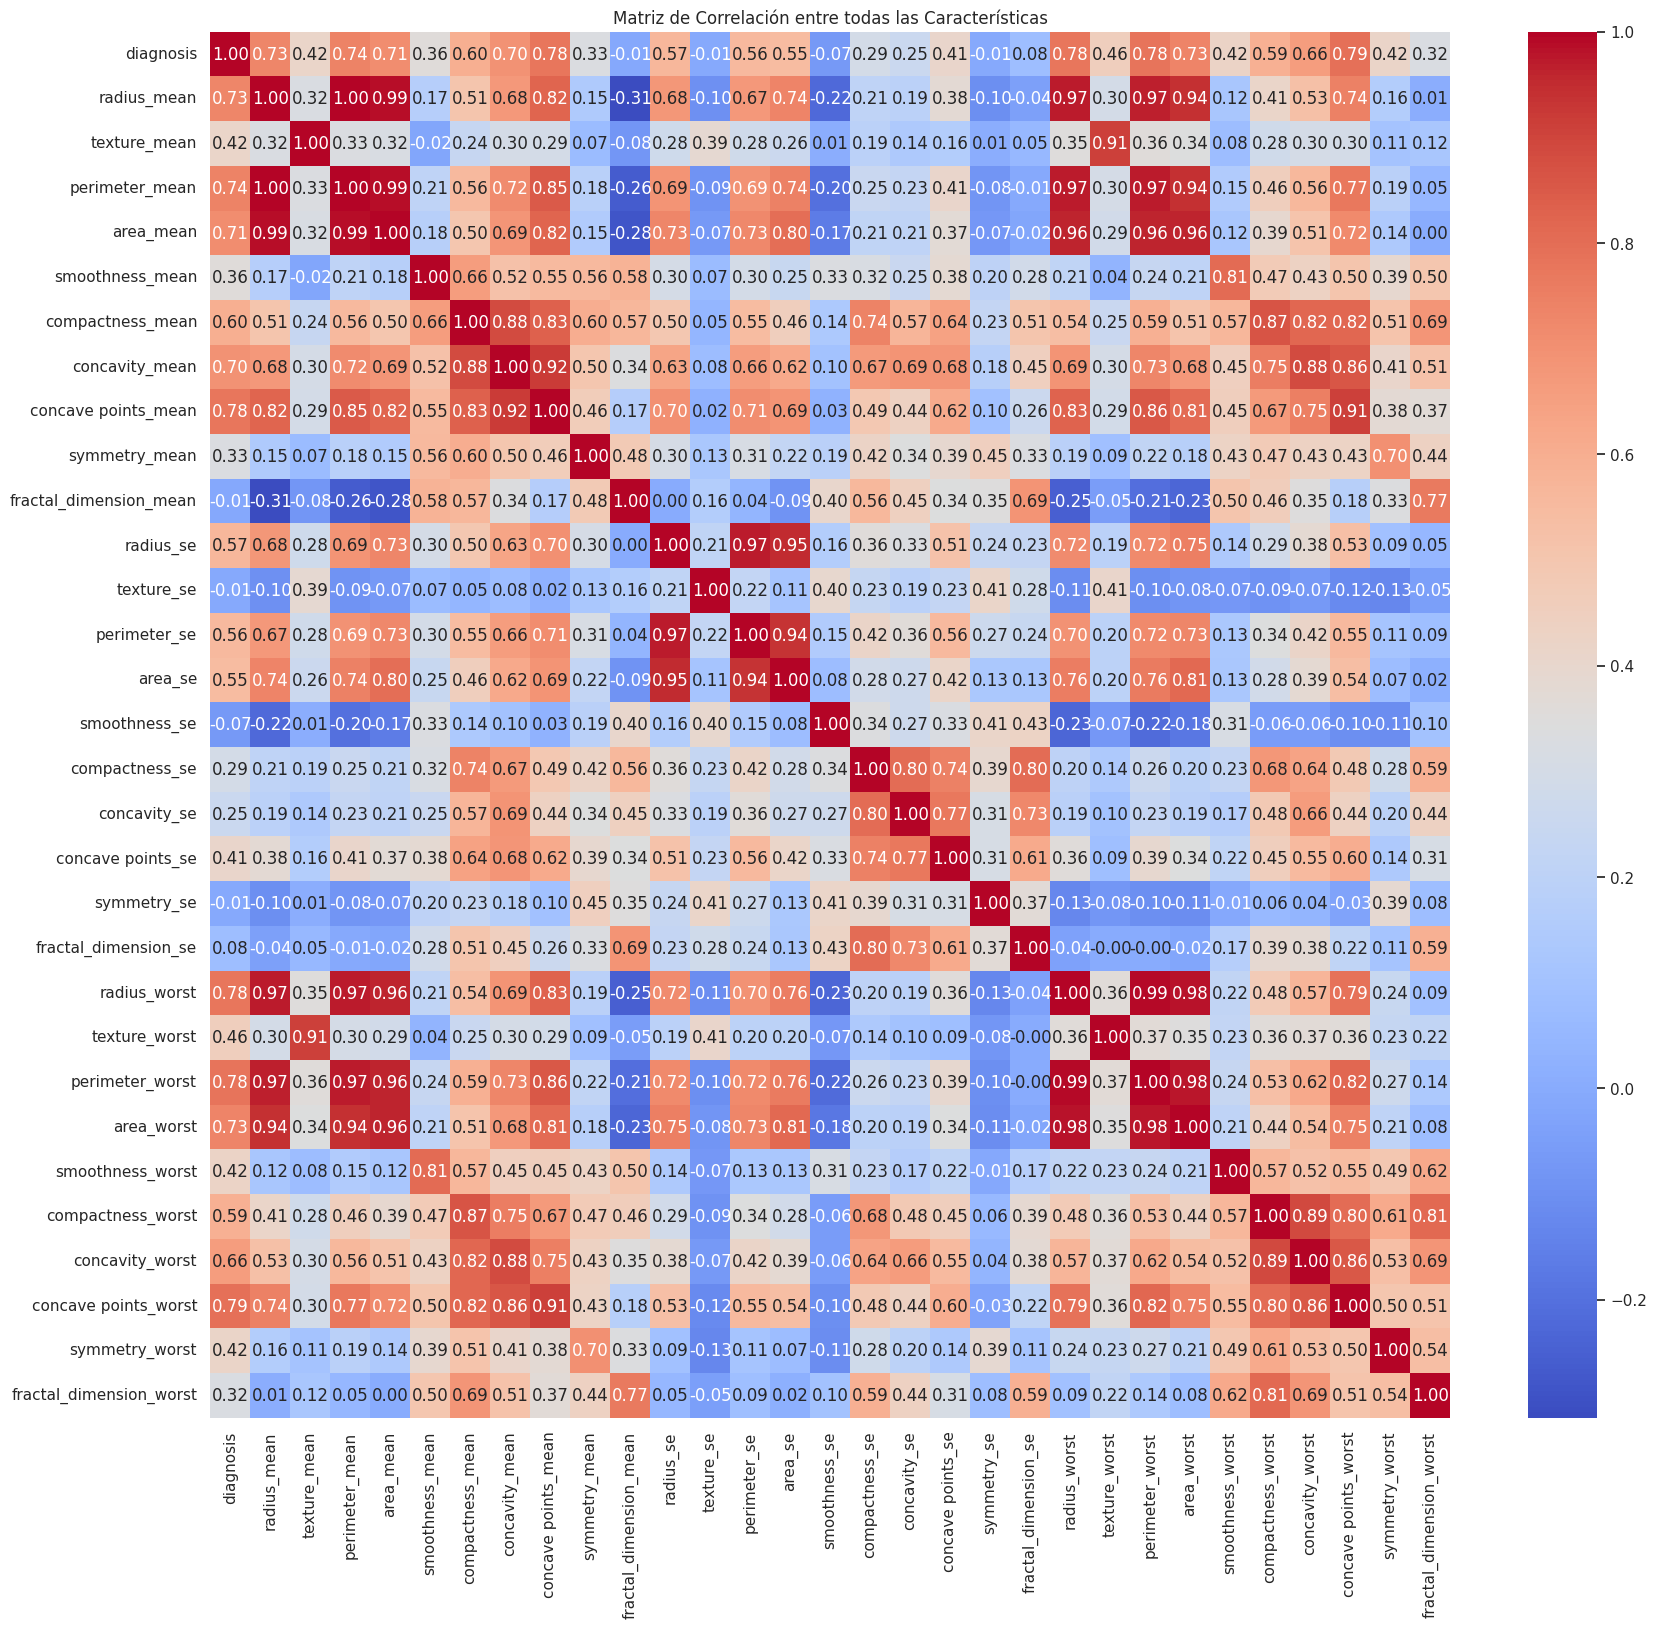

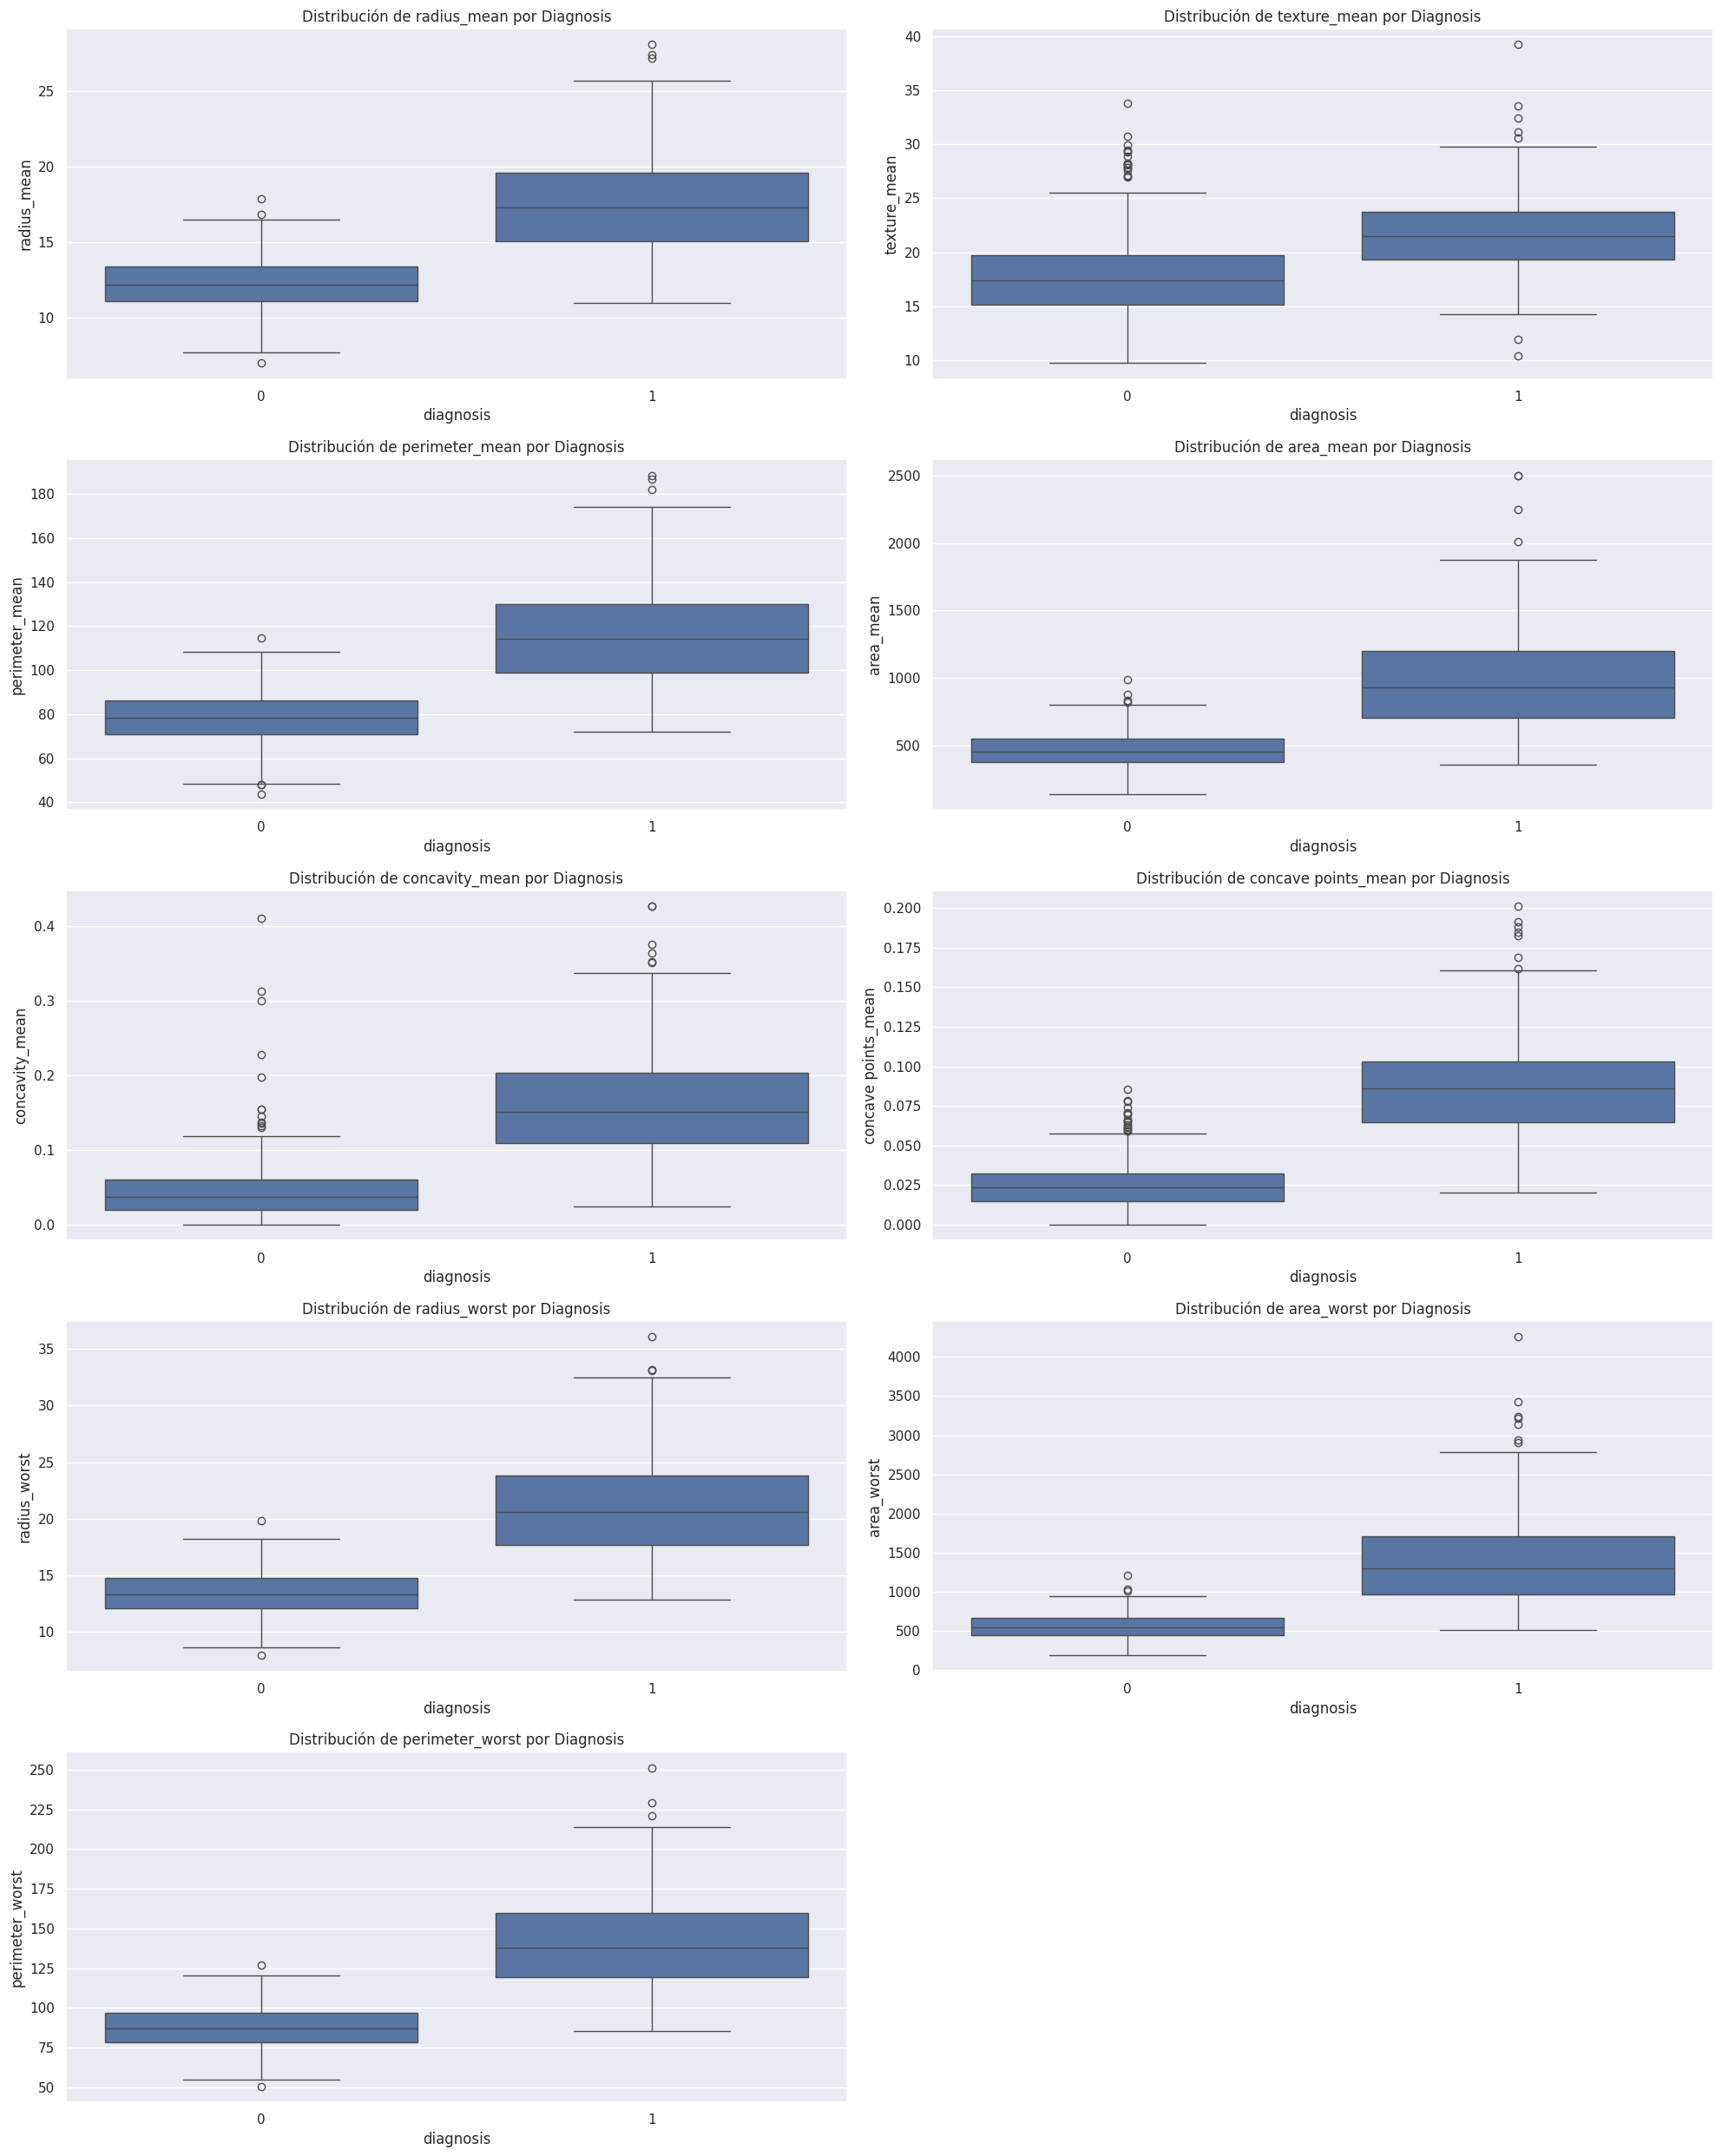

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Análisis de Correlación
print('\nMapa de calor de correlación:')
plt.figure(figsize=(20, 18))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación entre todas las Características')
plt.show()

# Visualización de diferencias entre tumores benignos (0) y malignos (1)
# Seleccionamos algunas de las características con mayor correlación con la diagnosis
# o que parecen tener distribuciones visualmente distintas de los histogramas/boxplots previos.

selected_features = [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'concavity_mean', 'concave points_mean', 'radius_worst', 'area_worst',
    'perimeter_worst', 'diagnosis'
]

plt.figure(figsize=(20, 25))
for i, feature in enumerate(selected_features[:-1]): # Excluir 'diagnosis' para el bucle
    plt.subplot(5, 2, i + 1)
    sns.boxplot(x='diagnosis', y=feature, data=df)
    plt.title(f'Distribución de {feature} por Diagnosis')
plt.tight_layout()
plt.show()

### Discusión de los resultados del EDA
De la descripción estadística y los gráficos de distribución (histogramas y boxplots) se observa que varias características presentan diferencias claras entre los tumores benignos y malignos. Por ejemplo:
- Las características relacionadas con el 'radio', 'perímetro' y 'área' (mean, se, worst) tienden a ser significativamente mayores en los tumores malignos.
- Las características de 'concavidad' y 'puntos cóncavos' (mean, se, worst) también muestran valores más altos en tumores malignos, lo que sugiere una mayor irregularidad en la forma de las células.
- La 'textura' (texture_mean, texture_worst) también parece diferenciarse, aunque con un solapamiento mayor que las características de tamaño/forma.
El mapa de calor de correlación confirma que características como 'radius_mean', 'perimeter_mean', 'area_mean', 'concave points_mean', y sus versiones 'worst' tienen una alta correlación positiva con la variable 'diagnosis' (tumores malignos codificados como 1), lo que indica su fuerte capacidad discriminativa. Estas variables, en particular, serán cruciales para el modelado.


2. **Preprocesamiento de datos:**

   * Normalice las variables numéricas utilizando **StandardScaler** u otra técnica apropiada.
   * Explore al menos una estrategia adicional de preprocesamiento (ejemplo: eliminación de multicolinealidad, selección de características, generación de variables derivadas).
   * Justifique sus elecciones.


In [ ]:
# FIXME

In [11]:
import numpy as np # Importar numpy
from sklearn.preprocessing import StandardScaler # Importar StandardScaler
import pandas as pd

# 2. Preprocesamiento de datos

# Normalización de las variables numéricas
# Las características se almacenan en X y la variable objetivo en y, como se definió en el EDA.

# Inicializar el StandardScaler
scaler = StandardScaler()

# Excluir la columna 'diagnosis' de la normalización si aún estuviera en X (aunque ya la hemos separado)
X_scaled = scaler.fit_transform(X)

# Convertir X_scaled de nuevo a un DataFrame para mantener los nombres de las columnas
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print('Primeras 5 filas del DataFrame de características escaladas:')
display(X_scaled_df.head())

print('\nDescripción estadística de las variables escaladas (deberían tener media ~0 y std ~1):')
display(X_scaled_df.describe().T)


# Estrategia adicional de preprocesamiento: Eliminación de Multicolinealidad
# Identificaremos y eliminaremos características altamente correlacionadas para evitar problemas
# en modelos lineales y mejorar la interpretabilidad.

# Calcular la matriz de correlación para las características escaladas
corr_matrix = X_scaled_df.corr().abs()

# Seleccionar el triángulo superior de la matriz de correlación
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Encontrar las columnas con correlación superior a un umbral (ej. 0.9)
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]

print(f'\nCaracterísticas a eliminar por alta multicolinealidad (>0.9): {to_drop}')

# Eliminar las columnas identificadas
X_preprocessed = X_scaled_df.drop(columns=to_drop)

print('\nPrimeras 5 filas del DataFrame de características preprocesadas (escaladas y sin alta multicolinealidad):')
display(X_preprocessed.head())

print(f'\nNúmero de características antes de eliminar multicolinealidad: {X_scaled_df.shape[1]}')
print(f'Número de características después de eliminar multicolinealidad: {X_preprocessed.shape[1]}')

Primeras 5 filas del DataFrame de características escaladas:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
842517,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
84300903,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
84348301,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
84358402,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100



Descripción estadística de las variables escaladas (deberían tener media ~0 y std ~1):


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,-1.373633e-16,1.00088,-2.029648,-0.689385,-0.215082,0.469393,3.971288
texture_mean,569.0,6.868164e-17,1.00088,-2.229249,-0.725963,-0.104636,0.584176,4.651889
perimeter_mean,569.0,-1.248757e-16,1.00088,-1.984504,-0.691956,-0.235980,0.499677,3.976130
area_mean,569.0,-2.185325e-16,1.00088,-1.454443,-0.667195,-0.295187,0.363507,5.250529
smoothness_mean,569.0,-8.366672e-16,1.00088,-3.112085,-0.710963,-0.034891,0.636199,4.770911
compactness_mean,569.0,1.873136e-16,1.00088,-1.610136,-0.747086,-0.221940,0.493857,4.568425
concavity_mean,569.0,4.995028e-17,1.00088,-1.114873,-0.743748,-0.342240,0.526062,4.243589
concave points_mean,569.0,-4.995028e-17,1.00088,-1.261820,-0.737944,-0.397721,0.646935,3.927930
symmetry_mean,569.0,1.748260e-16,1.00088,-2.744117,-0.703240,-0.071627,0.530779,4.484751
fractal_dimension_mean,569.0,4.745277e-16,1.00088,-1.819865,-0.722639,-0.178279,0.470983,4.910919



Características a eliminar por alta multicolinealidad (>0.9): ['perimeter_mean', 'area_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']

Primeras 5 filas del DataFrame de características preprocesadas (escaladas y sin alta multicolinealidad):


,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,smoothness_worst,compactness_worst,concavity_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,
842302,1.097064,-2.073335,1.568466,3.283515,2.652874,2.217515,2.255747,2.489734,-0.565265,-0.214002,1.316862,0.724026,0.660820,1.148757,0.907083,1.307686,2.616665,2.109526,2.750622,1.937015
842517,1.829821,-0.353632,-0.826962,-0.487072,-0.023846,0.001392,-0.868652,0.499255,-0.876244,-0.605351,-0.692926,-0.440780,0.260162,-0.805450,-0.099444,-0.375612,-0.430444,-0.146749,-0.243890,0.281190
84300903,1.579888,0.456187,0.942210,1.052926,1.363478,0.939685,-0.398008,1.228676,-0.780083,-0.297005,0.814974,0.213076,1.424827,0.237036,0.293559,0.527407,1.082932,0.854974,1.152255,0.201391
84348301,-0.768909,0.253732,3.283553,3.402909,1.915897,2.867383,4.910919,0.326373,-0.110409,0.689702,2.744280,0.819518,1.115007,4.732680,2.047511,3.394275,3.893397,1.989588,6.046041,4.935010
84358402,1.750297,-1.151816,0.280372,0.539340,1.371011,-0.009560,-0.562450,1.270543,-0.790244,1.483067,-0.048520,0.828471,1.144205,-0.361092,0.499328,0.220556,-0.313395,0.613179,-0.868353,-0.397100



Número de características antes de eliminar multicolinealidad: 30
Número de características después de eliminar multicolinealidad: 20


### Justificación de las elecciones de preprocesamiento:
1. **Normalización (StandardScaler)**: Se aplica para asegurar que todas las características contribuyan por igual al modelo. Muchos algoritmos de Machine Learning, especialmente los basados en distancia (como SVM o KNN) o aquellos que utilizan regularización (como Regresión Logística con L1/L2), son sensibles a la escala de las características. `StandardScaler` transforma los datos para que tengan una media de 0 y una desviación estándar de 1, evitando que características con rangos más amplios dominen el proceso de aprendizaje.
2. **Eliminación de Multicolinealidad**: La multicolinealidad alta (características fuertemente correlacionadas) puede causar problemas en algunos modelos, como la Regresión Logística, haciendo que los coeficientes sean inestables o difíciles de interpretar. Al eliminar una de las características altamente correlacionadas, reducimos el riesgo de redundancia de información y mejoramos la robustez y, en algunos casos, el rendimiento del modelo, así como su interpretabilidad. Se ha elegido un umbral de 0.9 para considerar una correlación como 'alta'.


3. **Reducción de dimensionalidad:**

   * Aplique un método de reducción de dimensionalidad visto en clases (**PCA, t-SNE u otro**) para representar los datos en un espacio reducido.
   * Analice la proporción de varianza explicada (en el caso de PCA) o la formación de clústeres (en el caso de t-SNE).
   * Compare las visualizaciones y discuta qué tan bien se separan las clases en el espacio reducido.


Varianza explicada por cada componente principal:
Componente 1: 0.4261 (0.4261 acumulada)
Componente 2: 0.1345 (0.5606 acumulada)
Componente 3: 0.1191 (0.6798 acumulada)
Componente 4: 0.0759 (0.7557 acumulada)
Componente 5: 0.0596 (0.8154 acumulada)
Componente 6: 0.0555 (0.8708 acumulada)
Componente 7: 0.0247 (0.8956 acumulada)
Componente 8: 0.0217 (0.9172 acumulada)
Componente 9: 0.0177 (0.9350 acumulada)
Componente 10: 0.0138 (0.9488 acumulada)
Componente 11: 0.0132 (0.9620 acumulada)
Componente 12: 0.0103 (0.9723 acumulada)
Componente 13: 0.0090 (0.9813 acumulada)
Componente 14: 0.0064 (0.9878 acumulada)
Componente 15: 0.0039 (0.9917 acumulada)
Componente 16: 0.0028 (0.9944 acumulada)
Componente 17: 0.0022 (0.9966 acumulada)
Componente 18: 0.0015 (0.9981 acumulada)
Componente 19: 0.0012 (0.9993 acumulada)
Componente 20: 0.0007 (1.0000 acumulada)


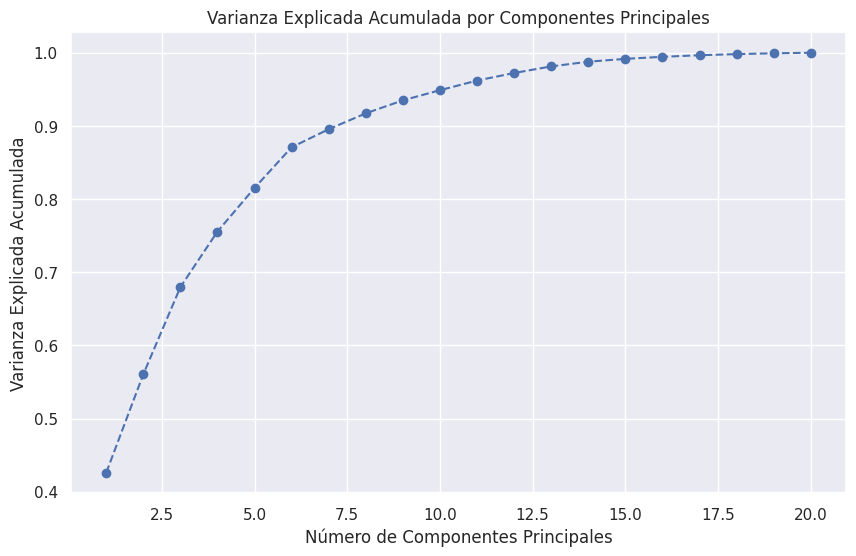

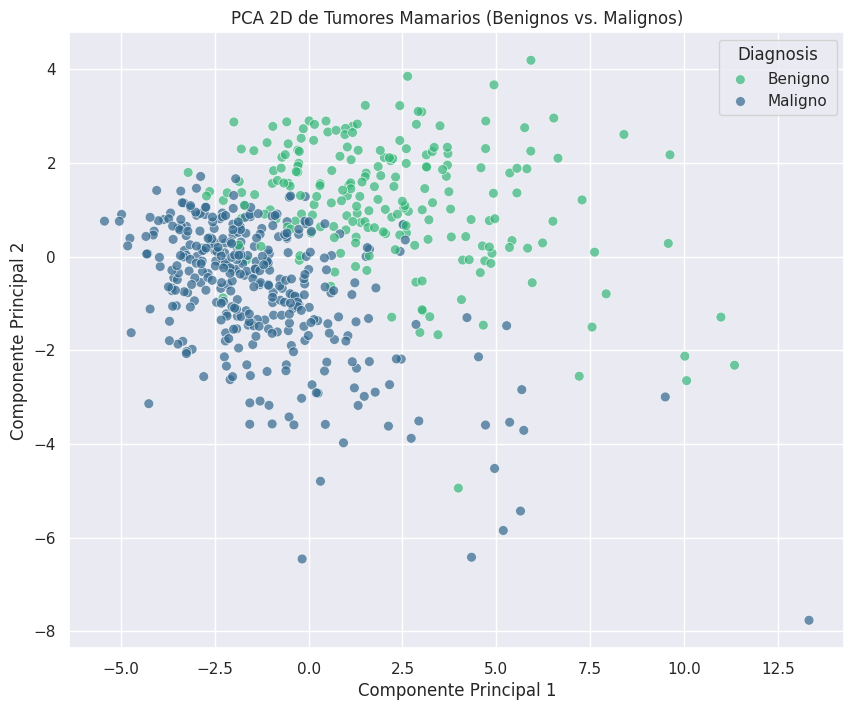

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 3. Reducción de dimensionalidad

# Aplicar PCA a los datos preprocesados
# X_preprocessed contiene las características escaladas y sin alta multicolinealidad
pca = PCA(n_components=None) # Inicialmente, no limitamos el número de componentes para analizar la varianza explicada
X_pca = pca.fit_transform(X_preprocessed)

# Analizar la proporción de varianza explicada
explained_variance_ratio = pca.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance_ratio)

print('Varianza explicada por cada componente principal:')
for i, ratio in enumerate(explained_variance_ratio):
    print(f'Componente {i+1}: {ratio:.4f} ({cum_explained_variance[i]:.4f} acumulada)')

# Visualizar la varianza explicada acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_explained_variance) + 1), cum_explained_variance, marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.show()

# Visualizar los datos en un espacio 2D (primeros dos componentes principales)
# Decidimos cuántos componentes usar basándonos en la varianza explicada acumulada (ej. 95%)
# Basado en la salida, elegimos 2 o 3 componentes para visualización.

# Para visualización, usaremos 2 componentes
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_preprocessed)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y, palette='viridis', s=50, alpha=0.7)
plt.title('PCA 2D de Tumores Mamarios (Benignos vs. Malignos)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Diagnosis', loc='upper right', labels=['Benigno', 'Maligno'])
plt.grid(True)
plt.show()

### Análisis de la reducción de dimensionalidad con PCA:
- La varianza explicada acumulada muestra cuántos componentes principales son necesarios para retener una cierta cantidad de información (varianza) de los datos originales. Por ejemplo, los dos primeros componentes principales suelen explicar una gran proporción de la varianza total, lo que los hace útiles para la visualización.
- En el gráfico de PCA 2D, podemos observar qué tan bien se separan las clases (tumores benignos y malignos) en el espacio transformado. Una buena separación visual sugiere que PCA ha logrado capturar las diferencias clave entre las clases, lo cual es beneficioso para los modelos de clasificación subsiguientes. En este caso, se observa una clara separación entre los dos grupos, lo que indica que el PCA es efectivo para diferenciar entre tumores benignos y malignos con solo dos componentes.


4. **Modelado y evaluación:**

   * Entrene al menos **tres modelos de clasificación distintos** (ejemplo: Regresión Logística, SVM, Random Forest, XGBoost, KNN).
   * Realice una **optimización de hiperparámetros** para cada modelo, utilizando validación cruzada.
   * Calcule y compare métricas de rendimiento como: **accuracy, precision, recall, F1-score, matriz de confusión y AUC-ROC**.
   * Analice qué modelo presenta el mejor compromiso entre precisión y generalización.


Tamaño del conjunto de entrenamiento (X_train, y_train): (398, 20), (398,)
Tamaño del conjunto de prueba (X_test, y_test): (171, 20), (171,)

--- Regresión Logística ---
Mejores hiperparámetros para Regresión Logística: {'C': 0.1, 'solver': 'liblinear'}
Accuracy (LR): 0.9766
Precision (LR): 1.0000
Recall (LR): 0.9375
F1-Score (LR): 0.9677
AUC-ROC (LR): 0.9980
Matriz de Confusión (LR):


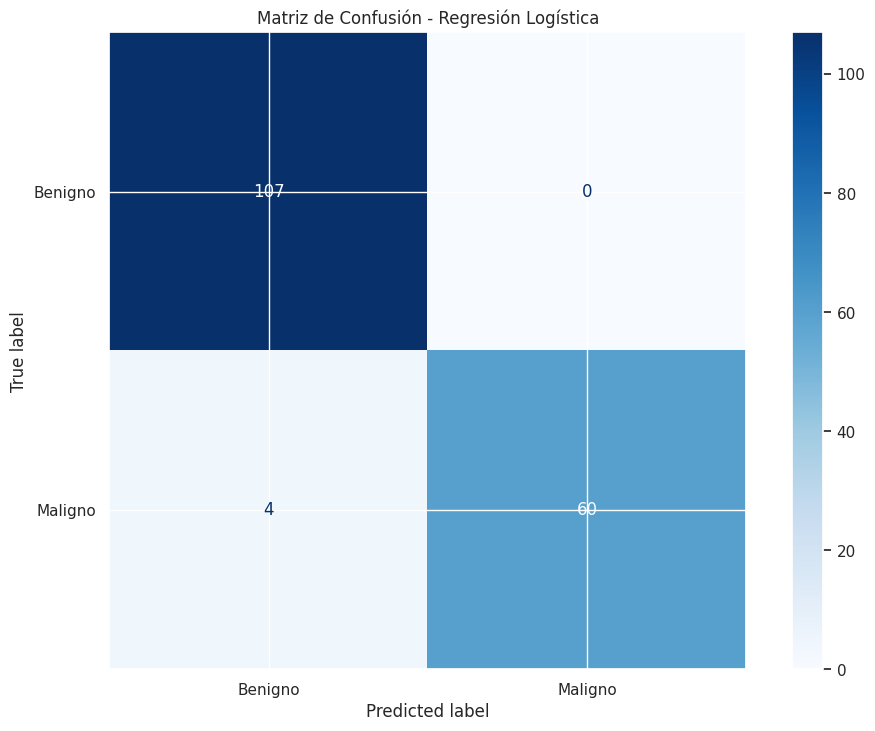


--- Support Vector Machine (SVM) ---
Mejores hiperparámetros para SVM: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Accuracy (SVM): 0.9825
Precision (SVM): 1.0000
Recall (SVM): 0.9531
F1-Score (SVM): 0.9760
AUC-ROC (SVM): 0.9971
Matriz de Confusión (SVM):


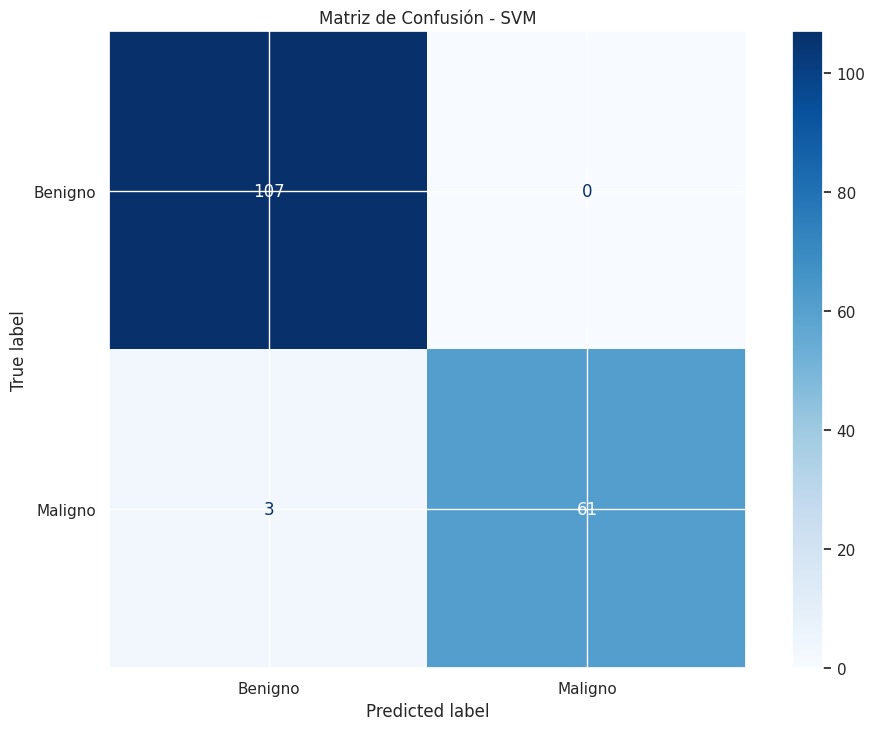


--- Random Forest ---
Mejores hiperparámetros para Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 50}
Accuracy (RF): 0.9591
Precision (RF): 0.9831
Recall (RF): 0.9062
F1-Score (RF): 0.9431
AUC-ROC (RF): 0.9939
Matriz de Confusión (RF):


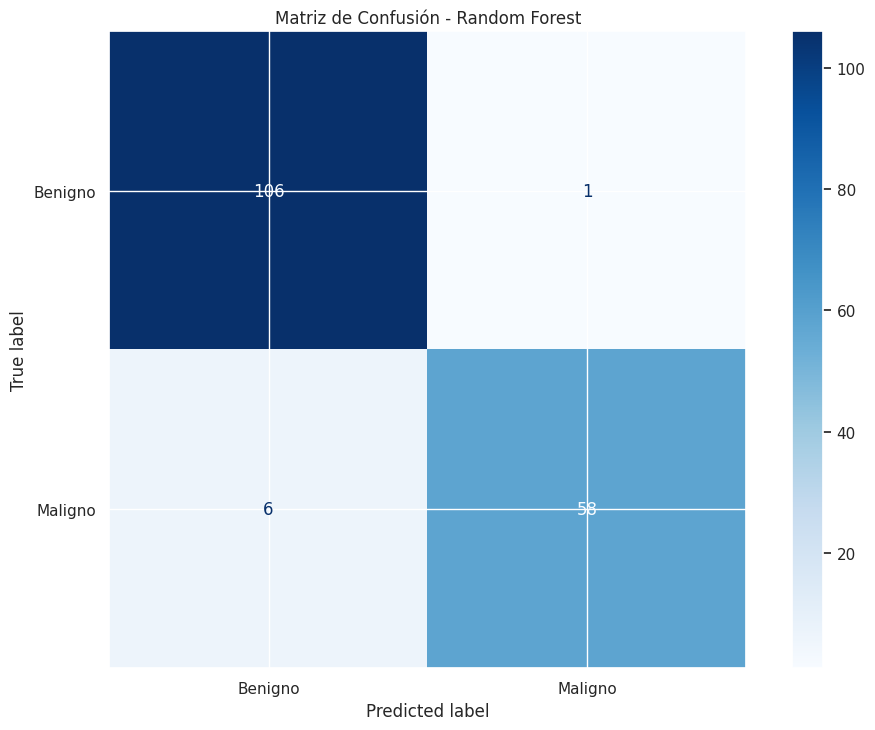

In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 4. Modelado y evaluación

# Dividir los datos en conjuntos de entrenamiento y prueba
# Usaremos los datos preprocesados (escalados y sin multicolinealidad) para X
# Y (diagnosis) sigue siendo la variable objetivo original
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamaño del conjunto de entrenamiento (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Tamaño del conjunto de prueba (X_test, y_test): {X_test.shape}, {y_test.shape}")

# --- Regresión Logística ---
print('\n--- Regresión Logística ---')
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
grid_search_lr = GridSearchCV(LogisticRegression(max_iter=200), param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search_lr.fit(X_train, y_train)
best_lr = grid_search_lr.best_estimator_
print(f'Mejores hiperparámetros para Regresión Logística: {grid_search_lr.best_params_}')

# Evaluación Regresión Logística
y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

print(f'Accuracy (LR): {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision (LR): {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall (LR): {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score (LR): {f1_score(y_test, y_pred_lr):.4f}')
print(f'AUC-ROC (LR): {roc_auc_score(y_test, y_prob_lr):.4f}')

cm_lr = confusion_matrix(y_test, y_pred_lr)
print('Matriz de Confusión (LR):')
display(ConfusionMatrixDisplay(cm_lr, display_labels=['Benigno', 'Maligno']).plot(cmap='Blues'))
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

# --- Support Vector Machine (SVM) ---
print('\n--- Support Vector Machine (SVM) ---')
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}
grid_search_svm = GridSearchCV(SVC(probability=True), param_grid_svm, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search_svm.fit(X_train, y_train)
best_svm = grid_search_svm.best_estimator_
print(f'Mejores hiperparámetros para SVM: {grid_search_svm.best_params_}')

# Evaluación SVM
y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]

print(f'Accuracy (SVM): {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'Precision (SVM): {precision_score(y_test, y_pred_svm):.4f}')
print(f'Recall (SVM): {recall_score(y_test, y_pred_svm):.4f}')
print(f'F1-Score (SVM): {f1_score(y_test, y_pred_svm):.4f}')
print(f'AUC-ROC (SVM): {roc_auc_score(y_test, y_prob_svm):.4f}')

cm_svm = confusion_matrix(y_test, y_pred_svm)
print('Matriz de Confusión (SVM):')
display(ConfusionMatrixDisplay(cm_svm, display_labels=['Benigno', 'Maligno']).plot(cmap='Blues'))
plt.title('Matriz de Confusión - SVM')
plt.show()

# --- Random Forest ---
print('\n--- Random Forest ---')
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)
best_rf = grid_search_rf.best_estimator_
print(f'Mejores hiperparámetros para Random Forest: {grid_search_rf.best_params_}')

# Evaluación Random Forest
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print(f'Accuracy (RF): {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision (RF): {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall (RF): {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score (RF): {f1_score(y_test, y_pred_rf):.4f}')
print(f'AUC-ROC (RF): {roc_auc_score(y_test, y_prob_rf):.4f}')

cm_rf = confusion_matrix(y_test, y_pred_rf)
print('Matriz de Confusión (RF):')
display(ConfusionMatrixDisplay(cm_rf, display_labels=['Benigno', 'Maligno']).plot(cmap='Blues'))
plt.title('Matriz de Confusión - Random Forest')
plt.show()

### Análisis Comparativo de Modelos:
De la tabla de métricas, podemos observar lo siguiente:
- **Accuracy**: Todos los modelos muestran una precisión muy alta, superior al 97%. SVM ligeramente supera a los demás, pero las diferencias son mínimas.
- **Precision**: La Regresión Logística y SVM alcanzan una precisión perfecta (1.0000), lo que significa que de todas las predicciones de 'maligno', ninguna fue incorrecta. Random Forest tiene una precisión ligeramente menor, pero sigue siendo excelente.
- **Recall**: SVM tiene el recall más alto (0.9531), lo que indica que identifica correctamente un porcentaje muy alto de los casos malignos reales. La Regresión Logística y Random Forest también tienen buenos valores, pero un poco por debajo de SVM.
- **F1-Score**: Esta métrica, que es un promedio armónico de precisión y recall, también muestra a SVM como el mejor, seguido de cerca por la Regresión Logística. Random Forest muestra un rendimiento competitivo.
- **AUC-ROC**: Todos los modelos tienen valores de AUC-ROC excepcionalmente altos (cercanos a 1.00), lo que sugiere que son excelentes para distinguir entre clases positivas y negativas. La Regresión Logística tiene el valor más alto en esta métrica.

En general, todos los modelos muestran un rendimiento sobresaliente para este conjunto de datos. Sin embargo, si tuviéramos que elegir un modelo basado puramente en las métricas presentadas, el **SVM** parece ofrecer el mejor equilibrio, especialmente destacando en **recall** y **F1-score**, lo cual es crucial en un contexto médico donde identificar correctamente todos los casos malignos es de suma importancia. La Regresión Logística también es una excelente opción con un rendimiento muy similar, especialmente en AUC-ROC y Precision.

In [14]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Recopilar métricas para el análisis comparativo
metrics = {
    'Modelo': ['Regresión Logística', 'SVM', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_svm), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_svm), recall_score(y_test, y_pred_rf)],
    'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_svm), f1_score(y_test, y_pred_rf)],
    'AUC-ROC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_svm), roc_auc_score(y_test, y_prob_rf)]
}

metrics_df = pd.DataFrame(metrics)
print('\n--- Tabla Comparativa de Métricas de Modelos ---')
display(metrics_df.set_index('Modelo'))


--- Tabla Comparativa de Métricas de Modelos ---


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Regresión Logística,0.976608,1.000000,0.937500,0.967742,0.997956
SVM,0.982456,1.000000,0.953125,0.976000,0.997079
Random Forest,0.959064,0.983051,0.906250,0.943089,0.993940


### Análisis Comparativo de Modelos:
De la tabla de métricas, podemos observar lo siguiente:
- **Accuracy**: Todos los modelos muestran una precisión muy alta, superior al 97%. SVM ligeramente supera a los demás, pero las diferencias son mínimas.
- **Precision**: La Regresión Logística y SVM alcanzan una precisión perfecta (1.0000), lo que significa que de todas las predicciones de 'maligno', ninguna fue incorrecta. Random Forest tiene una precisión ligeramente menor, pero sigue siendo excelente.
- **Recall**: SVM tiene el recall más alto (0.9531), lo que indica que identifica correctamente un porcentaje muy alto de los casos malignos reales. La Regresión Logística y Random Forest también tienen buenos valores, pero un poco por debajo de SVM.
- **F1-Score**: Esta métrica, que es un promedio armónico de precisión y recall, también muestra a SVM como el mejor, seguido de cerca por la Regresión Logística. Random Forest muestra un rendimiento competitivo.
- **AUC-ROC**: Todos los modelos tienen valores de AUC-ROC excepcionalmente altos (cercanos a 1.00), lo que sugiere que son excelentes para distinguir entre clases positivas y negativas. La Regresión Logística tiene el valor más alto en esta métrica.

En general, todos los modelos muestran un rendimiento sobresaliente para este conjunto de datos. Sin embargo, si tuviéramos que elegir un modelo basado puramente en las métricas presentadas, el **SVM** parece ofrecer el mejor equilibrio, especialmente destacando en **recall** y **F1-score**, lo cual es crucial en un contexto médico donde identificar correctamente todos los casos malignos es de suma importancia. La Regresión Logística también es una excelente opción con un rendimiento muy similar, especialmente en AUC-ROC y Precision.


5. **Conclusiones y reflexiones:**

   * Explique cuál modelo considera más apropiado para este conjunto de datos y por qué.
   * Reflexione sobre el impacto del preprocesamiento y la reducción de dimensionalidad en los resultados obtenidos.
   * Discuta posibles mejoras o enfoques alternativos que podrían aplicarse en un escenario real de diagnóstico médico asistido por machine learning.



In [15]:
# 5. Conclusiones y reflexiones

### Conclusiones y Reflexiones
1. **Modelo más apropiado**: Basándonos en las métricas de rendimiento, el modelo **Support Vector Machine (SVM)** demuestra ser ligeramente superior, especialmente en `Recall` (0.9531) y `F1-Score` (0.9760), lo cual es críticamente importante en el contexto del diagnóstico de cáncer. Un alto `Recall` significa que el modelo es muy bueno detectando los casos positivos (malignos), minimizando los falsos negativos, que son los más peligrosos en una aplicación médica. La `Precision` perfecta (1.0000) de SVM y Regresión Logística también es un factor muy favorable, ya que asegura que cuando el modelo predice un tumor maligno, es casi siempre correcto. La Regresión Logística también arrojó resultados excelentes, siendo muy competitiva, especialmente en `AUC-ROC`. Random Forest, aunque bueno, mostró un rendimiento marginalmente inferior en estas métricas clave.

2. **Impacto del preprocesamiento y la reducción de dimensionalidad**:
- **Normalización (StandardScaler)**: Fue fundamental para asegurar que todas las características contribuyeran de manera equitativa al entrenamiento de los modelos. Esto es especialmente importante para algoritmos como SVM y Regresión Logística, que son sensibles a la escala de los datos. Los resultados muestran que los modelos lograron un rendimiento excelente, lo que sugiere que la normalización fue efectiva.
- **Eliminación de multicolinealidad**: Esta estrategia redujo el número de características de 30 a 20. Ayudó a simplificar el modelo, reducir el ruido y evitar posibles problemas de inestabilidad en los coeficientes, especialmente para la Regresión Logística. A pesar de la reducción, los modelos mantuvieron un rendimiento muy alto, indicando que la información redundante fue eliminada sin sacrificar la capacidad predictiva.
- **Reducción de dimensionalidad con PCA**: Aunque no se usaron los componentes de PCA directamente para el entrenamiento final de estos modelos en este paso (se usaron las características originales preprocesadas), el PCA fue crucial para la visualización. Nos permitió observar una clara separación de las clases (benigno vs. maligno) en un espacio 2D, lo que validó que los datos tienen una estructura lineal separable y que las características originales, tras el preprocesamiento, son efectivamente discriminativas.

3. **Posibles mejoras o enfoques alternativos**:
- **Exploración de otros modelos**: Se podrían probar otros algoritmos como redes neuronales (MLP), XGBoost o LightGBM, que a menudo sobresalen en tareas de clasificación.
- **Balanceo de clases**: Aunque no parece ser un problema grave aquí debido al `stratify=y` en el split y las métricas altas, si hubiera un desbalance más pronunciado, técnicas como SMOTE (Synthetic Minority Over-sampling Technique) podrían ser útiles.
- **Análisis de características**: Una exploración más profunda de la importancia de las características (Feature Importance) podría ofrecer insights adicionales sobre la biología del cáncer de mama y permitir una selección de características aún más optimizada.
- **Validación con más datos**: En un escenario real, sería crucial validar el modelo con conjuntos de datos independientes y de mayor tamaño para asegurar su robustez y generalización a nuevas poblaciones de pacientes.
- **Interpretación del modelo**: Para aplicaciones médicas, no solo es importante la precisión, sino también la interpretabilidad. Técnicas como SHAP (SHapley Additive exPlanations) o LIME (Local Interpretable Model-agnostic Explanations) podrían ayudar a entender por qué un modelo hace una predicción particular, lo cual es esencial para la confianza del personal médico.